In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_generation.fair_world import simulate_fair_world


from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import (
    MLP,
    train_epoch,
    evaluate,
    train,
    plot,
    train_mlp_model
)

from src.metrics.fairness import (
    fairness_by_group,
    equal_opportunity_diff,
    equalized_odds_diff
)

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
device


'mps'

In [26]:
df = simulate_fair_world(10000)
df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,1,20.899377,84.280031,5.407856,0
1,2,0,69.805709,189.437552,6.724400,1
2,1,0,41.805177,70.442825,5.449826,0
3,2,0,57.418190,111.758084,4.967218,0
4,1,0,29.471795,126.836947,6.393756,1


In [27]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 8000
Test size: 2000
Prevalence: 0.211


In [28]:
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)


In [29]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUC:", lr_results["AUROC"])


LR Accuracy: 0.9975
LR AUC: 0.9999603386130572


Epoch 1/20: train_loss=0.1305, train_acc=99.71, val_loss=0.0115, val_acc=99.75
Epoch 2/20: train_loss=0.0057, train_acc=99.85, val_loss=0.0081, val_acc=99.75
Epoch 3/20: train_loss=0.0041, train_acc=99.85, val_loss=0.0069, val_acc=99.80
Epoch 4/20: train_loss=0.0036, train_acc=99.85, val_loss=0.0058, val_acc=99.80
Epoch 5/20: train_loss=0.0033, train_acc=99.88, val_loss=0.0057, val_acc=99.75
Epoch 6/20: train_loss=0.0029, train_acc=99.89, val_loss=0.0071, val_acc=99.80
Epoch 7/20: train_loss=0.0031, train_acc=99.86, val_loss=0.0065, val_acc=99.75
Epoch 8/20: train_loss=0.0028, train_acc=99.88, val_loss=0.0059, val_acc=99.75
Epoch 9/20: train_loss=0.0027, train_acc=99.91, val_loss=0.0067, val_acc=99.70
Epoch 10/20: train_loss=0.0025, train_acc=99.89, val_loss=0.0070, val_acc=99.75
Epoch 11/20: train_loss=0.0025, train_acc=99.89, val_loss=0.0058, val_acc=99.80
Epoch 12/20: train_loss=0.0024, train_acc=99.88, val_loss=0.0060, val_acc=99.80
Epoch 13/20: train_loss=0.0021, train_acc=99.90, 

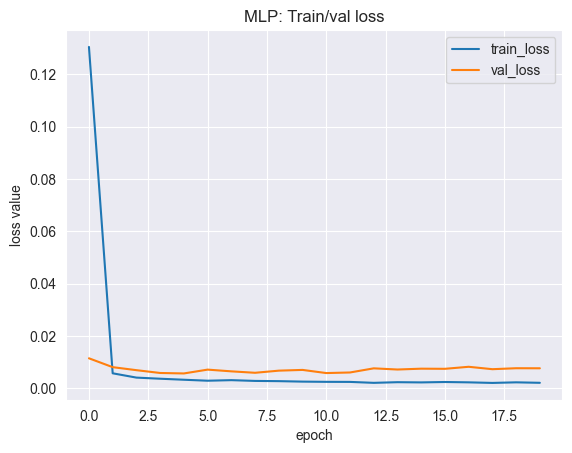

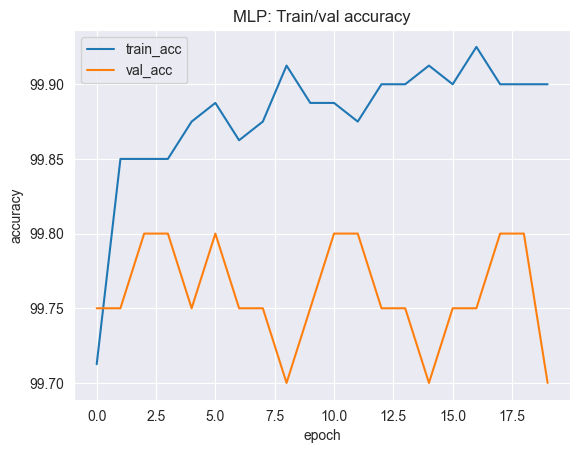

In [30]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUC:", mlp_results["AUROC"])


In [31]:
# --------------------------
# LR Fairness
# --------------------------
print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], race_test)
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], gender_test)
print(lr_fair_gender)

LR_EO_race   = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)


# --------------------------
# MLP Fairness
# --------------------------
print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], race_test)
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], gender_test)
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
   FPR       FNR       TPR  TNR
0  0.0  0.016736  0.983264  1.0
1  0.0  0.010989  0.989011  1.0
2  0.0  0.000000  1.000000  1.0

=== LR Fairness by Gender ===
   FPR       FNR       TPR  TNR
0  0.0  0.010050  0.989950  1.0
1  0.0  0.015544  0.984456  1.0

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.002081  0.012552  0.987448  0.997919
1  0.000000  0.010989  0.989011  1.000000
2  0.000000  0.000000  1.000000  1.000000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.002574  0.010050  0.989950  0.997426
1  0.000000  0.010363  0.989637  1.000000


In [32]:
results_fair = {
    "world_name": "Fair",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_fair
